In [1]:
%load_ext autoreload
%autoreload 2
import os
import json
from persona_based_prediction_llm_runner import PersonaBasedPredictionLLMRunner
import pandas as pd

In [2]:
# Set up stuff
country_a = "EGY"
country_b = "USA"
wave_a = 5
wave_b = 6
wave_c = 7

In [3]:
question_prefixes_to_skip = ['E179']

significant_changes_path = '/home/tchakrab/gb-scratch/wvs/data/significant_changes/ks'
prefixes = ['A']
country_a_sig_changes_a_to_b = []
country_a_sig_changes_b_to_c = []
country_b_sig_changes_a_to_b = []
country_b_sig_changes_b_to_c = []

for question_prefix in prefixes:
    sig_changes_a_to_b = pd.read_csv(f'{significant_changes_path}/{question_prefix}_wave{wave_a}_to_wave{wave_b}.csv')
    # remove from this any rows where the "question" starts with any of the question_prefixes_to_skip
    sig_changes_a_to_b = sig_changes_a_to_b[~sig_changes_a_to_b['question'].str.startswith(tuple(question_prefixes_to_skip))]
    # get the changes and add
    sig_changes_a = sig_changes_a_to_b[sig_changes_a_to_b['country'] == country_a]
    sig_changes_b = sig_changes_a_to_b[sig_changes_a_to_b['country'] == country_b]
    country_a_sig_changes_a_to_b.extend(sig_changes_a['question'].tolist())
    country_b_sig_changes_a_to_b.extend(sig_changes_b['question'].tolist())
    
    sig_changes_b_to_c = pd.read_csv(f'{significant_changes_path}/{question_prefix}_wave{wave_b}_to_wave{wave_c}.csv')
    # remove from this any rows where the "question" starts with any of the question_prefixes_to_skip
    sig_changes_b_to_c = sig_changes_b_to_c[~sig_changes_b_to_c['question'].str.startswith(tuple(question_prefixes_to_skip))]
    # get the changes and add
    sig_changes_a = sig_changes_b_to_c[sig_changes_b_to_c['country'] == country_a]
    sig_changes_b = sig_changes_b_to_c[sig_changes_b_to_c['country'] == country_b]
    country_a_sig_changes_b_to_c.extend(sig_changes_a['question'].tolist())
    country_b_sig_changes_b_to_c.extend(sig_changes_b['question'].tolist())

#  now for country a and b, get a list of questions common between the two wave sets
country_a_target_questions = set(country_a_sig_changes_a_to_b).intersection(set(country_a_sig_changes_b_to_c))
country_b_target_questions = set(country_b_sig_changes_a_to_b).intersection(set(country_b_sig_changes_b_to_c))

#  print how many questions in each
print(f'Country {country_a} has {len(country_a_target_questions)} target questions between the two wave sets.')
print(f'Country {country_b} has {len(country_b_target_questions)} target questions between the two wave sets.')
#  print how many common between the two countries
common_questions_between_countries = set(country_a_target_questions).intersection(set(country_b_target_questions))
print(f'The two countries have {len(common_questions_between_countries)} common questions between them.')

Country EGY has 30 target questions between the two wave sets.
Country USA has 39 target questions between the two wave sets.
The two countries have 30 common questions between them.


In [4]:
if len(country_a_target_questions) > 0 and len(country_b_target_questions) > 0:
    runner = PersonaBasedPredictionLLMRunner()

Loading cached averages...


In [5]:
results_path = '/home/tchakrab/gb-scratch/wvs/results/results_new'
#  check for the parsed files for country a
country_a_wave_a_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_a}_{wave_a}.json')
country_a_wave_b_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_a}_{wave_b}.json')
country_a_wave_c_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_a}_{wave_c}.json')

#  check for the parsed files for country b
country_b_wave_a_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_b}_{wave_a}.json')
country_b_wave_b_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_b}_{wave_b}.json')
country_b_wave_c_parsed = os.path.join(results_path, f'persona_based_prediction_parsed_{country_b}_{wave_c}.json')

# Country a LLM calls
if not os.path.exists(country_a_wave_a_parsed):
    country_a_wave_a_raw, country_a_wave_a_parsed = runner.run_full_pipeline(country_a, wave_a, target_questions=country_a_target_questions)
if not os.path.exists(country_a_wave_b_parsed):
    country_a_wave_b_raw, country_a_wave_b_parsed = runner.run_full_pipeline(country_a, wave_b, target_questions=country_a_target_questions)
if not os.path.exists(country_a_wave_c_parsed):
    country_a_wave_c_raw, country_a_wave_c_parsed = runner.run_full_pipeline(country_a, wave_c, target_questions=country_a_target_questions)

#  country b LLM calls
if not os.path.exists(country_b_wave_a_parsed):
    country_b_wave_a_raw, country_b_wave_a_parsed = runner.run_full_pipeline(country_b, wave_a, target_questions=country_b_target_questions)
if not os.path.exists(country_b_wave_b_parsed):
    country_b_wave_b_raw, country_b_wave_b_parsed = runner.run_full_pipeline(country_b, wave_b, target_questions=country_b_target_questions)
if not os.path.exists(country_b_wave_c_parsed):
    country_b_wave_c_raw, country_b_wave_c_parsed = runner.run_full_pipeline(country_b, wave_c, target_questions=country_b_target_questions)


Creating prompts (Batched Question Mode, Deduplicated)...
Loading Data for USA, Wave 5...
Generated 3735 UNIQUE prompts.
Running LLM...


Processing Batch:  60%|██████████████████████████████████████████████████████████████▌                                          | 2226/3735 [01:04<00:46, 32.49conv/s]Error in generate_explanation: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}
Returning empty dictionary
Processing Batch: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 3735/3735 [02:24<00:00, 25.84conv/s]
Processing failed for 1 instances, retrying
Processing Batch: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:08<0

Parsing results...
Creating prompts (Batched Question Mode, Deduplicated)...
Loading Data for USA, Wave 6...
Generated 6513 UNIQUE prompts.
Running LLM...


Processing Batch:   7%|███████▉                                                                                                  | 484/6513 [00:13<02:14, 44.80conv/s]Error in generate_explanation: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}
Returning empty dictionary
Processing Batch:  32%|█████████████████████████████████▋                                                                       | 2089/6513 [00:52<01:52, 39.36conv/s]Error in generate_explanation: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. 

Parsing results...
Creating prompts (Batched Question Mode, Deduplicated)...
Loading Data for USA, Wave 7...
Generated 7710 UNIQUE prompts.
Running LLM...


Processing Batch: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 7710/7710 [03:34<00:00, 35.98conv/s]


Parsing results...


In [6]:
# Read the parsed results and create delta 
#  read the results for country_a for wave_a and wave_b

#  Country a
with open(country_a_wave_a_parsed, 'r') as f:
    country_a_wave_a_data = json.load(f)
    # convert to df
    country_a_wave_a_df = pd.DataFrame.from_dict(country_a_wave_a_data, orient='index')
    country_a_wave_a_df = country_a_wave_a_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(country_a_wave_b_parsed, 'r') as f:
    country_a_wave_b_data = json.load(f)
    country_a_wave_b_df = pd.DataFrame.from_dict(country_a_wave_b_data, orient='index')
    country_a_wave_b_df = country_a_wave_b_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(country_a_wave_c_parsed, 'r') as f:
    country_a_wave_c_data = json.load(f)
    country_a_wave_c_df = pd.DataFrame.from_dict(country_a_wave_c_data, orient='index')
    country_a_wave_c_df = country_a_wave_c_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)

# Country b
with open(country_b_wave_a_parsed, 'r') as f:
    country_b_wave_a_data = json.load(f)
    country_b_wave_a_df = pd.DataFrame.from_dict(country_b_wave_a_data, orient='index')
    country_b_wave_a_df = country_b_wave_a_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(country_b_wave_b_parsed, 'r') as f:    
    country_b_wave_b_data = json.load(f)
    country_b_wave_b_df = pd.DataFrame.from_dict(country_b_wave_b_data, orient='index')
    country_b_wave_b_df = country_b_wave_b_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(country_b_wave_c_parsed, 'r') as f:
    country_b_wave_c_data = json.load(f)
    country_b_wave_c_df = pd.DataFrame.from_dict(country_b_wave_c_data, orient='index')
    country_b_wave_c_df = country_b_wave_c_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)

import numpy as np
# for each column, compute the average across all rows for all the dfs, and store in separate dicts
dfs = {'country_a_wave_a_df': country_a_wave_a_df,
       'country_a_wave_b_df': country_a_wave_b_df,
       'country_a_wave_c_df': country_a_wave_c_df,
       'country_b_wave_a_df': country_b_wave_a_df,
       'country_b_wave_b_df': country_b_wave_b_df,
       'country_b_wave_c_df': country_b_wave_c_df}

average_results = {}
for df_name, df in dfs.items():
    average_results[df_name] = {}
    for column in df.columns:
        # check if the column is numeric
        if pd.api.types.is_numeric_dtype(df[column]):
            average_results[df_name][column] = np.mean(df[column])
        else:
            average_results[df_name][column] = None


In [7]:
deltas_country_a_llm = {}
for question in country_a_target_questions:
    if question not in average_results['country_a_wave_b_df'] or question not in average_results['country_a_wave_c_df']:
        continue
    # if the averge_resul is none, skip the question
    if average_results['country_a_wave_b_df'][question] is not None and average_results['country_a_wave_c_df'][question] is not None:
        deltas_country_a_llm[question] = {
            'delta_1': average_results['country_a_wave_b_df'][question] - average_results['country_a_wave_a_df'][question],
            'delta_2': average_results['country_a_wave_c_df'][question] - average_results['country_a_wave_b_df'][question]
        }
deltas_country_b_llm = {}
for question in country_b_target_questions:
    if question not in average_results['country_b_wave_b_df'] or question not in average_results['country_b_wave_c_df']:
        continue
    if average_results['country_b_wave_b_df'][question] is not None and average_results['country_b_wave_c_df'][question] is not None:
        deltas_country_b_llm[question] = {
            'delta_1': average_results['country_b_wave_b_df'][question] - average_results['country_b_wave_a_df'][question],
            'delta_2': average_results['country_b_wave_c_df'][question] - average_results['country_b_wave_b_df'][question]
        }

In [8]:
#  for these questions, get the real answers
import pandas as pd
question_prefix = 'A'
wave_a_to_b = pd.read_csv(f'{significant_changes_path}/{question_prefix}_wave{wave_a}_to_wave{wave_b}.csv')
wave_b_to_c = pd.read_csv(f'{significant_changes_path}/{question_prefix}_wave{wave_b}_to_wave{wave_c}.csv')

deltas_country_a_real = {}
for question in deltas_country_a_llm.keys():
    row_a_b = wave_a_to_b[(wave_a_to_b['country'] == country_a) & (wave_a_to_b['question'] == question)]
    delta_a_b = row_a_b['mean_wave_' + str(wave_b)].values[0] - row_a_b['mean_wave_' + str(wave_a)].values[0]

    row_b_c = wave_b_to_c[(wave_b_to_c['country'] == country_a) & (wave_b_to_c['question'] == question)]
    delta_b_c = row_b_c['mean_wave_' + str(wave_c)].values[0] - row_b_c['mean_wave_' + str(wave_b)].values[0]
        
    deltas_country_a_real[question] = {'delta_1': delta_a_b, 'delta_2': delta_b_c}

deltas_country_b_real = {}
for question in deltas_country_b_llm.keys():
    row_a_b = wave_a_to_b[(wave_a_to_b['country'] == country_b) & (wave_a_to_b['question'] == question)]
    delta_a_b = row_a_b['mean_wave_' + str(wave_b)].values[0] - row_a_b['mean_wave_' + str(wave_a)].values[0]

    row_b_c = wave_b_to_c[(wave_b_to_c['country'] == country_b) & (wave_b_to_c['question'] == question)]
    delta_b_c = row_b_c['mean_wave_' + str(wave_c)].values[0] - row_b_c['mean_wave_' + str(wave_b)].values[0]
        
    deltas_country_b_real[question] = {'delta_1': delta_a_b, 'delta_2': delta_b_c}

In [9]:
# for country a, get the questions common between the deltas llm and real
common_questions_a = set(deltas_country_a_llm.keys()).intersection(set(deltas_country_a_real.keys()))
common_questions_b = set(deltas_country_b_llm.keys()).intersection(set(deltas_country_b_real.keys()))
print(f'For country {country_a}, there are {len(common_questions_a)} common questions between the LLM deltas and the real deltas.')
print(f'For country {country_b}, there are {len(common_questions_b)} common questions between the LLM deltas and the real deltas.')

For country EGY, there are 20 common questions between the LLM deltas and the real deltas.
For country USA, there are 29 common questions between the LLM deltas and the real deltas.


In [10]:
import matplotlib.pyplot as plt
import itertools

def plot_dict_trajectories(dict1, dict2, wave1, wave2, wave3, country):
    """
    Generates side-by-side scatter plots for two dictionaries containing delta_1 and delta_2.
    Ensures that identical keys share the exact same marker and color across both plots.
    """
    # 1. Define sets of markers and colors to mix and match
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', '<', '>']
    colors = plt.cm.tab10.colors  # Standard 10-color palette

    # Create a list of unique (marker, color) combinations
    styles = list(itertools.product(markers, colors))

    # 2. Identify common keys to plot
    common_keys = list(set(dict1.keys()).intersection(dict2.keys()))
    common_keys.sort() # Sorting ensures the legend is in a predictable order
    
    # Pre-map each key to a specific style to ensure consistency
    style_mapping = {}
    for i, key in enumerate(common_keys):
        style_mapping[key] = styles[i % len(styles)]

    # Setup the figure for side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # 3. Iterate through keys and plot on both axes
    for key in common_keys:
        marker_style, color_style = style_mapping[key]
        
        # Plot for dictionary 1
        ax1.scatter(dict1[key]['delta_1'], dict1[key]['delta_2'], 
                    label=key, s=150, marker=marker_style, color=color_style,
                    alpha=0.9, edgecolor='black', linewidth=0.5)
        
        # Plot for dictionary 2
        ax2.scatter(dict2[key]['delta_1'], dict2[key]['delta_2'], 
                    label=key, s=150, marker=marker_style, color=color_style,
                    alpha=0.9, edgecolor='black', linewidth=0.5)

    # 4. Formatting and Quadrant Lines for both plots
    for ax, title in zip([ax1, ax2], [f'LLM Deltas for {country}', f'Real Deltas for {country}']):
        ax.axhline(0, color='black', linewidth=1, alpha=0.5)
        ax.axvline(0, color='black', linewidth=1, alpha=0.5)
        
        ax.set_xlabel(f'Wave {wave1} to Wave {wave2}', fontsize=12)
        ax.set_ylabel(f'Wave {wave2} to Wave {wave3}', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.grid(True, linestyle=':', alpha=0.6)

    # 5. Place a single, shared legend outside the subplots
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, title="Keys", bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=9, ncol=1)

    plt.tight_layout()
    plt.show()

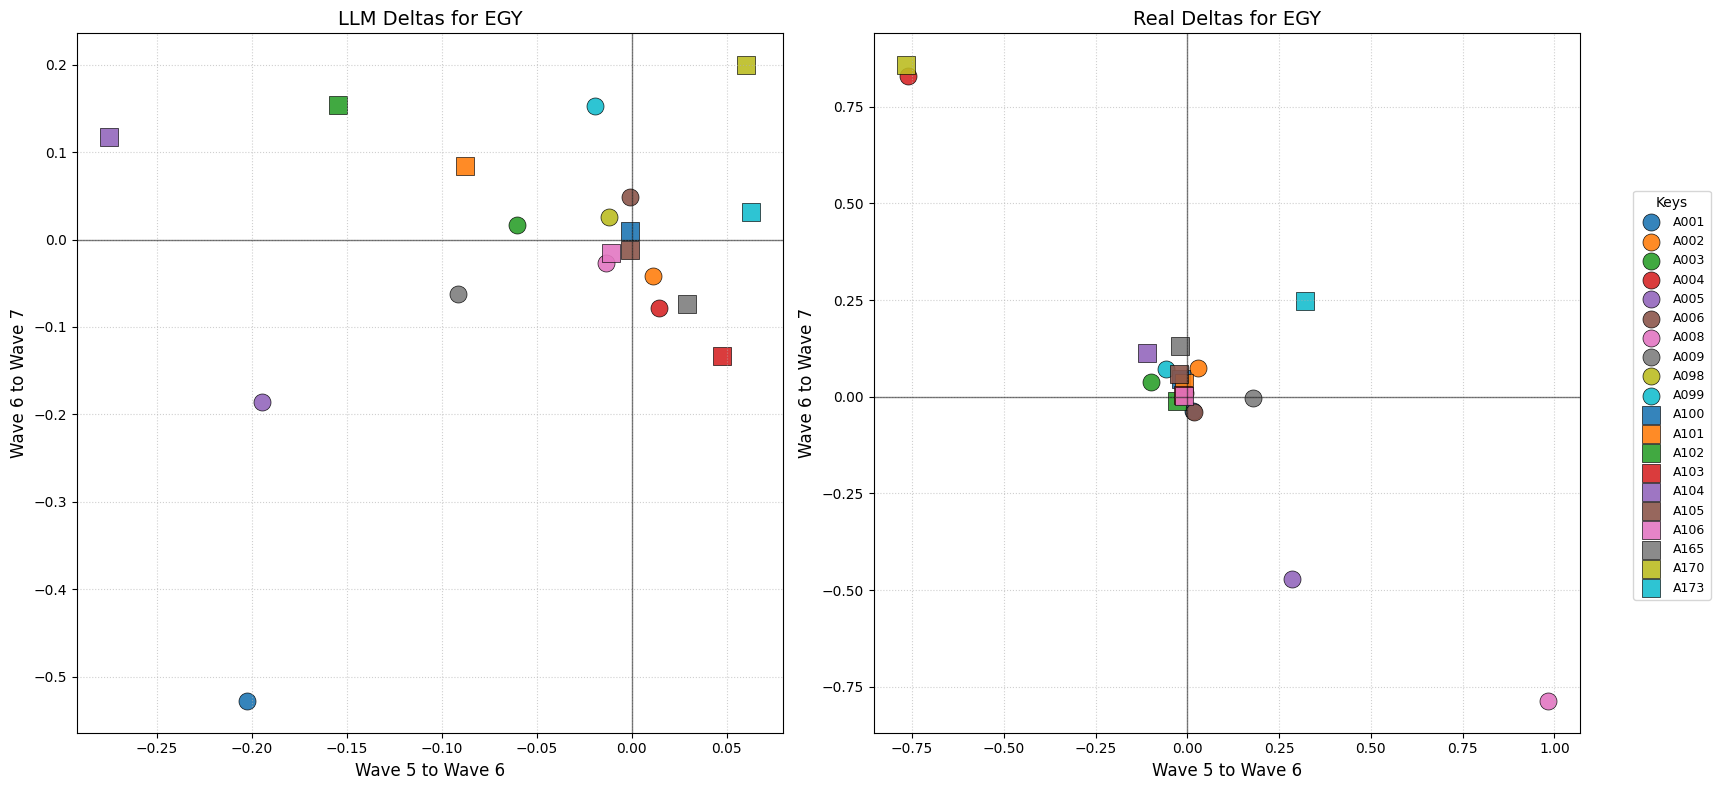

In [13]:
plot_dict_trajectories(deltas_country_a_llm, deltas_country_a_real, wave_a, wave_b, wave_c, country_a)

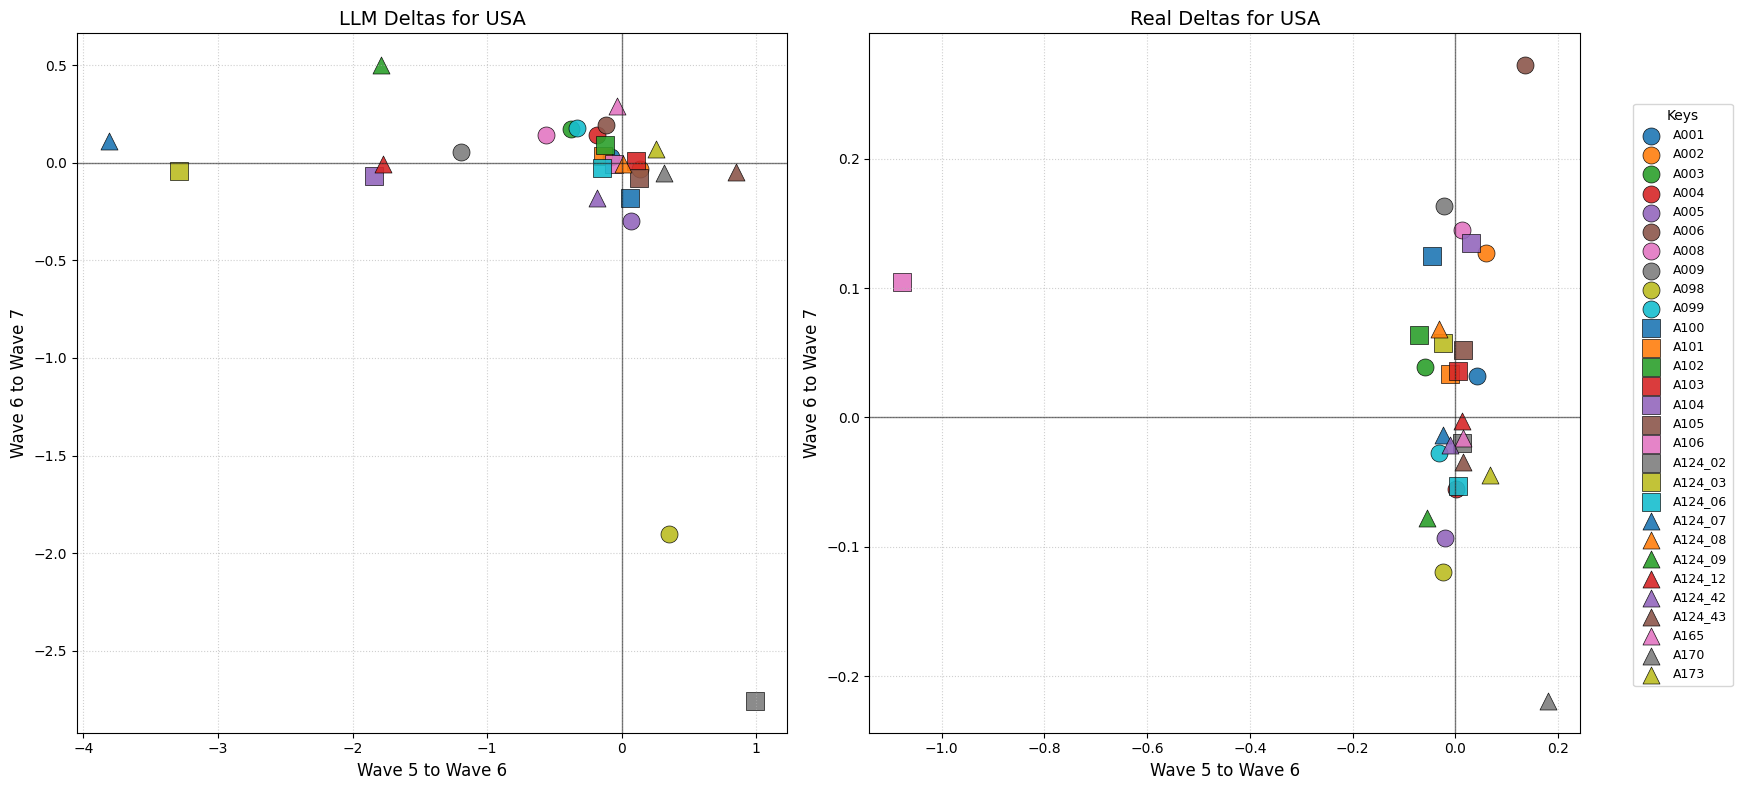

In [12]:
plot_dict_trajectories(deltas_country_b_llm, deltas_country_b_real, wave_a, wave_b, wave_c, country_b)